In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy

# Load image
image = cv2.imread("D:/Wallpers/123.jpg", cv2.IMREAD_GRAYSCALE)

# ---------- Noise Functions ----------
def add_gaussian_noise(image, mean=0, std=20):
    noise = np.random.normal(mean, std, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 255)

def add_salt_pepper_noise(image, salt_prob=0.05, pepper_prob=0.05):
    noisy = image.copy()

    # Salt
    num_salt = int(salt_prob * image.size)
    coords = [np.random.randint(0, i, num_salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255

    # Pepper
    num_pepper = int(pepper_prob * image.size)
    coords = [np.random.randint(0, i, num_pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0

    return noisy

def add_uniform_noise(image, low=0, high=50):
    noise = np.random.uniform(low, high, image.shape)
    return np.clip(image + noise, 0, 255)

# ---------- Display ----------
def show_image_and_hist(img, title):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title(title)

    plt.subplot(1,2,2)
    plt.hist(img.ravel(), bins=256)
    plt.title("Histogram")

    plt.show()

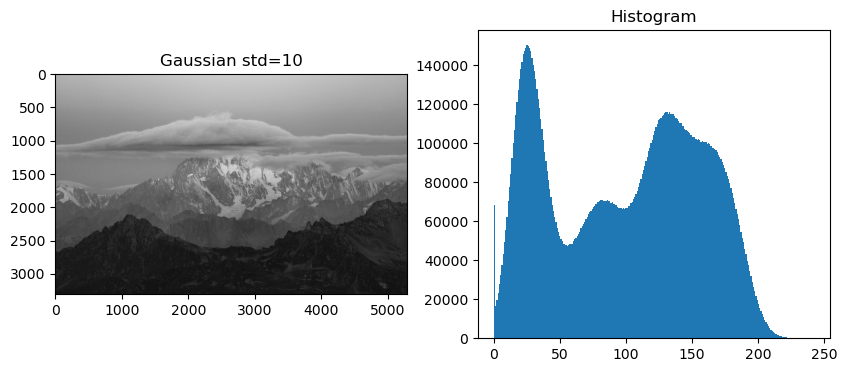

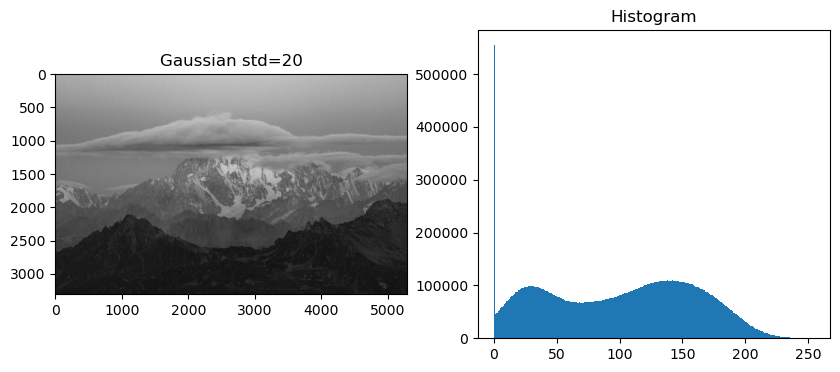

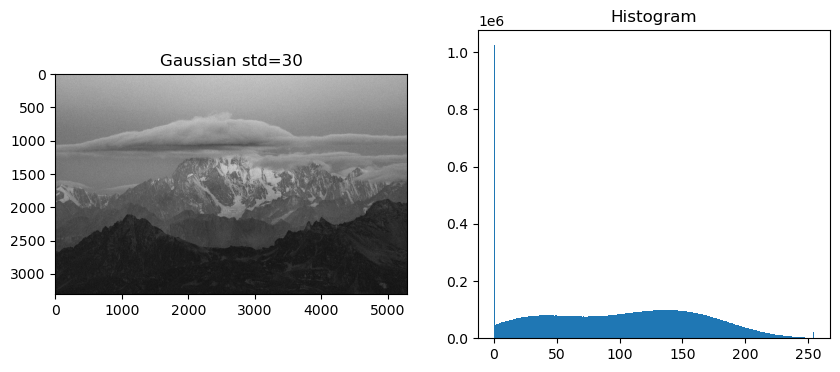

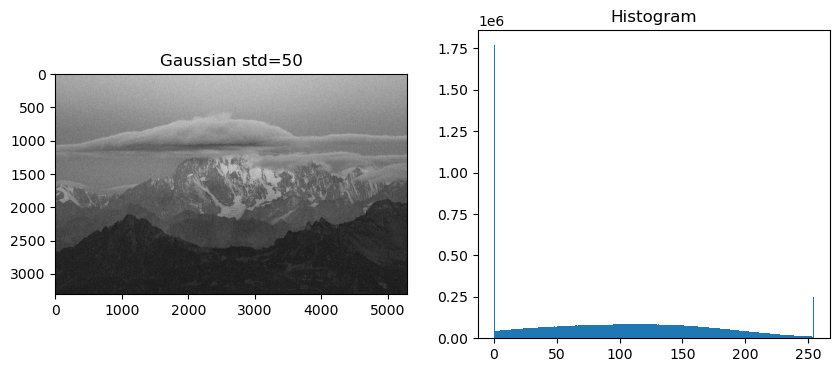

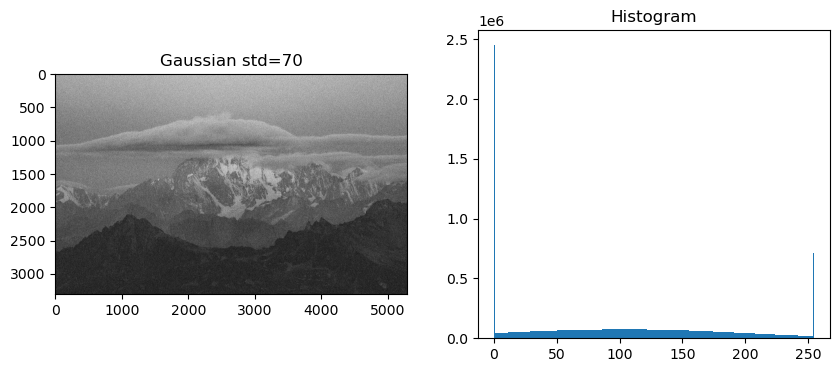

In [3]:
for std in [10, 20, 30, 50, 70]:
    noisy = add_gaussian_noise(image, 0, std)
    show_image_and_hist(noisy, f"Gaussian std={std}")

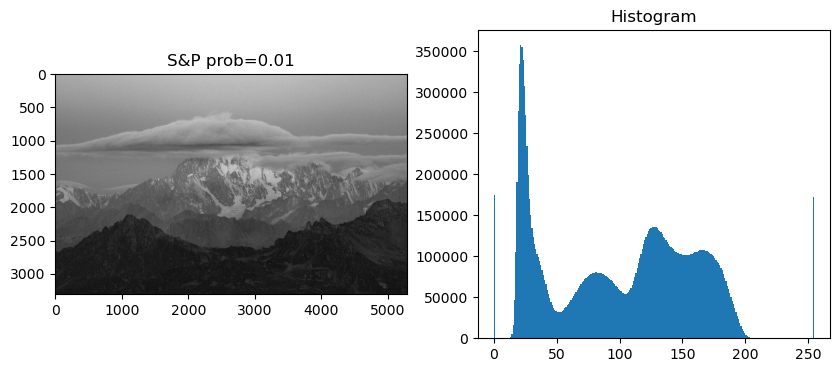

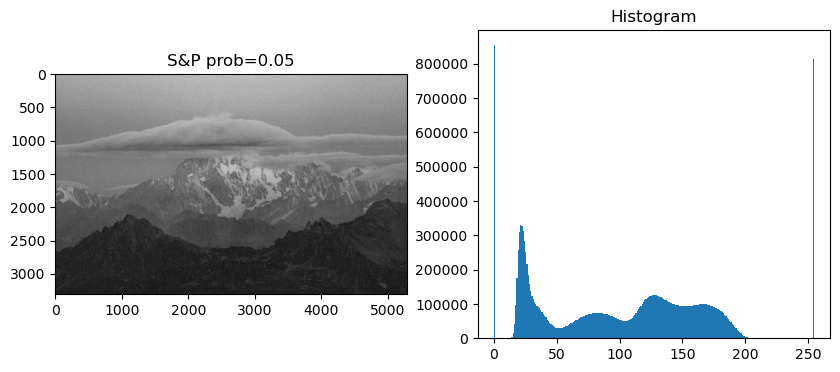

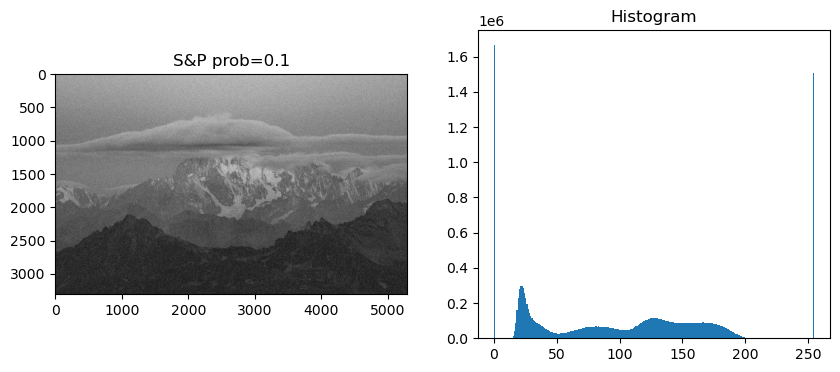

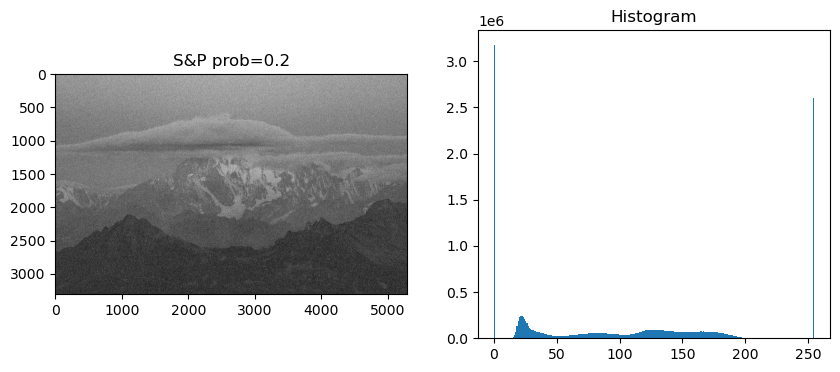

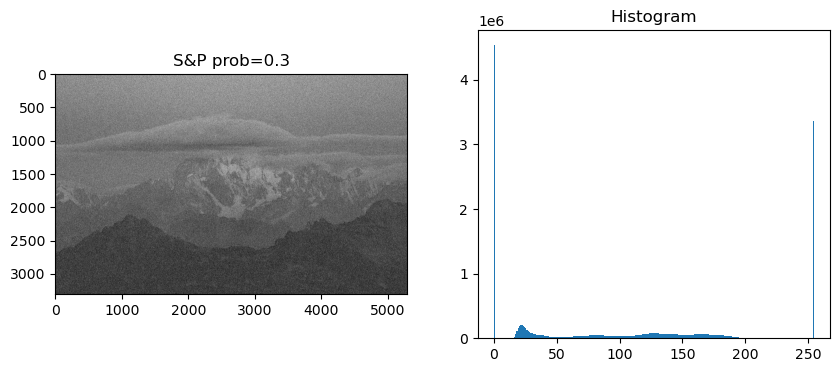

In [4]:
probs = [0.01, 0.05, 0.1, 0.2, 0.3]

for p in probs:
    noisy = add_salt_pepper_noise(image, p, p)
    show_image_and_hist(noisy, f"S&P prob={p}")

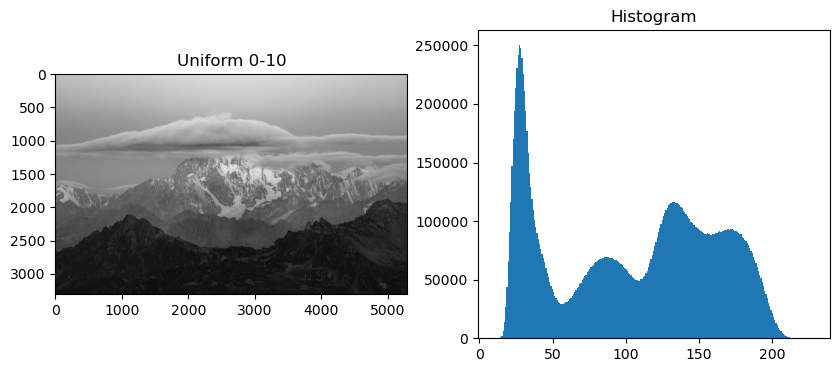

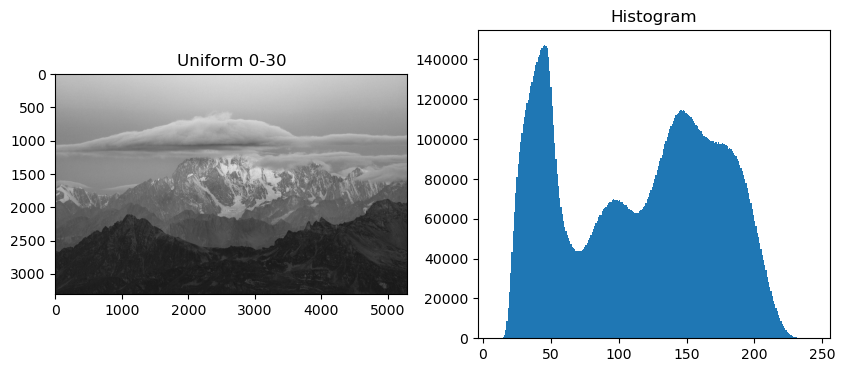

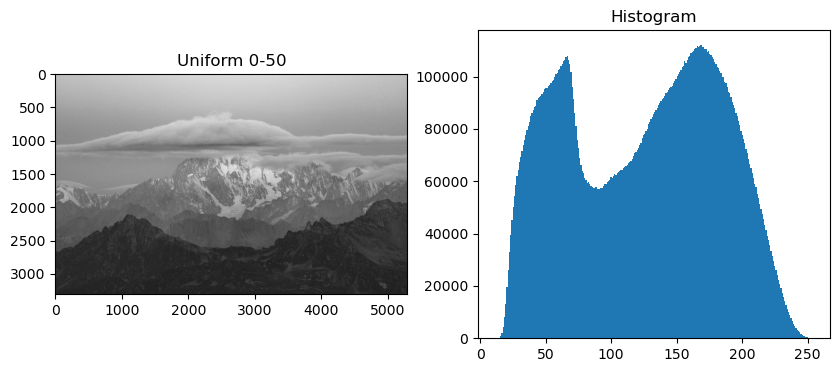

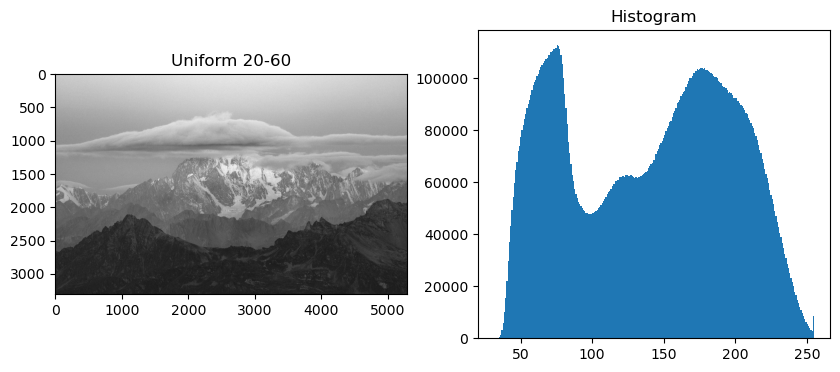

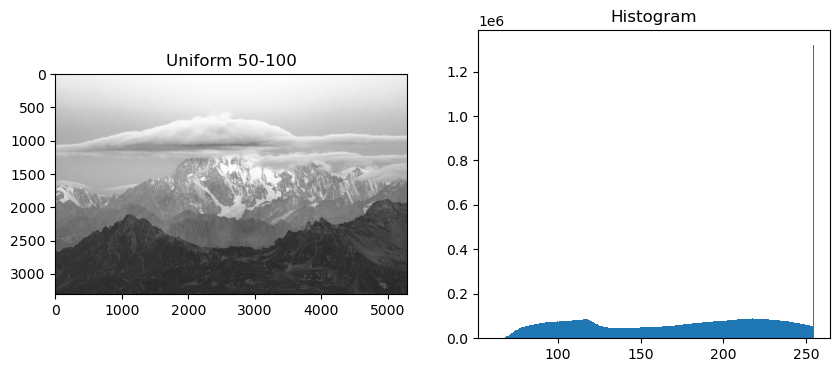

In [5]:
ranges = [(0,10), (0,30), (0,50), (20,60), (50,100)]

for low, high in ranges:
    noisy = add_uniform_noise(image, low, high)
    show_image_and_hist(noisy, f"Uniform {low}-{high}")

In [6]:
def median_filter(image, size):
    pad = size // 2
    padded = np.pad(image, pad, mode='symmetric')
    result = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+size, j:j+size]
            result[i,j] = np.median(patch)

    return result

In [7]:
def geometric_mean_filter(image, size):
    pad = size // 2
    padded = np.pad(image, pad, mode='symmetric')
    result = np.zeros_like(image, dtype=float)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+size, j:j+size]
            result[i,j] = np.exp(np.mean(np.log(patch + 1)))

    return result

In [8]:
def harmonic_mean_filter(image, size):
    pad = size // 2
    padded = np.pad(image, pad, mode='symmetric')
    result = np.zeros_like(image, dtype=float)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+size, j:j+size]
            result[i,j] = (size*size) / np.sum(1/(patch+1))

    return result

In [9]:
def min_filter(image, size):
    pad = size // 2
    padded = np.pad(image, pad, mode='symmetric')
    result = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+size, j:j+size]
            result[i,j] = np.min(patch)

    return result

def max_filter(image, size):
    pad = size // 2
    padded = np.pad(image, pad, mode='symmetric')
    result = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            patch = padded[i:i+size, j:j+size]
            result[i,j] = np.max(patch)

    return result

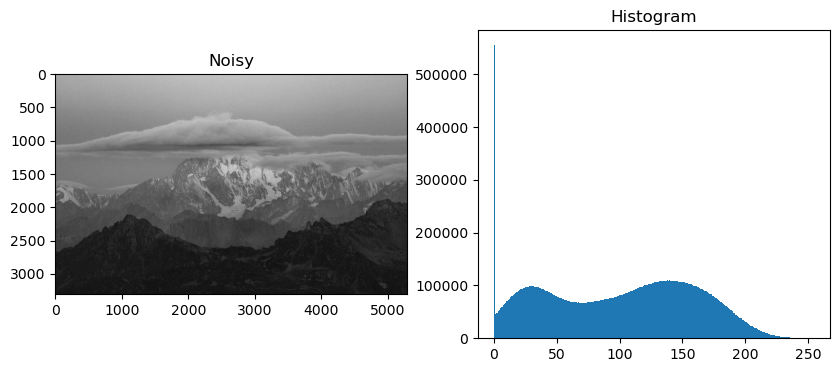

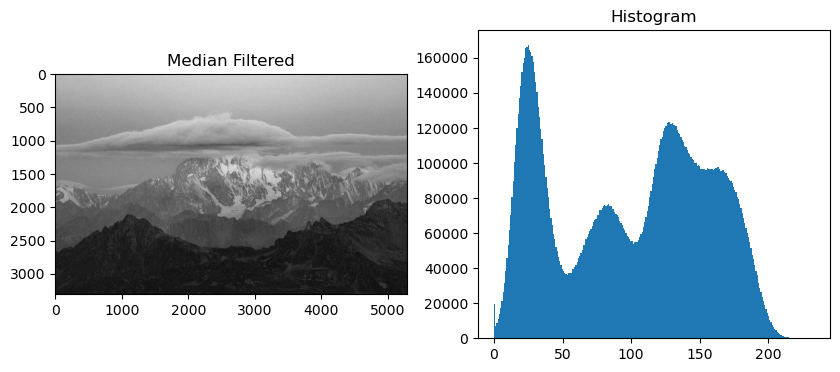

In [10]:
noisy = add_gaussian_noise(image, 0, 20)
filtered = median_filter(noisy, 3)

show_image_and_hist(noisy, "Noisy")
show_image_and_hist(filtered, "Median Filtered")